<a href="https://colab.research.google.com/github/anshupandey/iimlddpm26/blob/main/flowboard_python_product_thinking_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐍 Python for Product Thinking in the AI Era

## Data-Driven Product Development — Executive Program

---

**Welcome!** This notebook is your hands-on companion for the next 3–4 hours. Everything here is designed around a single fictional product — **FlowBoard**, a project management SaaS platform — so insights compound as we go.

### What you'll accomplish today

By the end of this session, you'll answer three real product questions using Python + AI:

| # | Product Question | Method |
|---|---|---|
| 1 | **Which feature should we kill?** | Feature adoption analysis across segments |
| 2 | **Should we ship variant A or B?** | A/B test interpretation with hidden segment insights |
| 3 | **What are customers really saying?** | AI-powered feedback mining and theme extraction |

### How this notebook works

- **Every Python concept is taught through a product example** — no abstract exercises
- **Markdown cells** (like this one) explain context and product thinking
- **Code cells** are meant to be run — hit `Shift+Enter` to execute each one
- **🎯 Exercise** blocks are for you to try yourself
- **💡 Product Insight** blocks highlight what the analysis means for decisions
- **🤖 AI Moment** blocks show where AI accelerates the workflow

### About FlowBoard

FlowBoard is a project management and collaboration SaaS (think simplified Asana/Monday.com) with:
- **3 plan tiers**: Free, Pro, Enterprise
- **12 features**: from Kanban Board to API Access
- **600 users** across tiers with 6 months of usage data
- **Active experiments**, customer feedback, and daily KPIs

Let's begin.


---

# Part 1: Why Python + Just Enough Foundations

## 1.1 Setting Up Our Environment

First, let's import the libraries we'll use throughout the session and load our data.


THere are 4 pillars of any programming language:


1. Data Types - core data types (string, integer), derived (list, tuple, dictionary)
2. Control Flow - (if else, loops - for, while)
3. Functions - code blocks embedded into a single command
4. Object Oriented Programming

In [1]:
# integer
x = 5
y = 6
print(x+y)

11


In [2]:
# Integer
age = 30
print(f"Age: {age}, Type: {type(age)}")

# Float
price = 19.99
print(f"Price: {price}, Type: {type(price)}")

# String
product_name = "FlowBoard Pro"
print(f"Product Name: {product_name}, Type: {type(product_name)}")

# Boolean
is_active = True
print(f"Is Active: {is_active}, Type: {type(is_active)}")

Age: 30, Type: <class 'int'>
Price: 19.99, Type: <class 'float'>
Product Name: FlowBoard Pro, Type: <class 'str'>
Is Active: True, Type: <class 'bool'>


In [4]:
# list
numberofHours_usage = [2,3,4,3,2,3,4,5]

# calucate average usage

## core python way
avg = sum(numberofHours_usage)/len(numberofHours_usage)
print(avg)

# using a package
import numpy as np
avg = np.mean(numberofHours_usage)
print(avg)


3.25
3.25


In [11]:
# Core libraries — these are pre-installed in Google Colab
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make our charts look clean
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print("✅ Libraries loaded successfully!")
print(f"   pandas version: {pd.__version__}")
print(f"   numpy version: {np.__version__}")


✅ Libraries loaded successfully!
   pandas version: 2.2.2
   numpy version: 2.0.2


### Loading the FlowBoard datasets

In Google Colab, you'll upload the CSV files or mount Google Drive. For now, let's load them directly.

> **Colab tip:** To upload files, use the file browser on the left sidebar, or run:
> ```python
> from google.colab import files
> uploaded = files.upload()
> ```


In [13]:
# Load all FlowBoard datasets
# Adjust these paths if your files are in a different location

events = pd.read_csv('https://raw.githubusercontent.com/anshupandey/iimlddpm26/refs/heads/main/flowboard_user_events.csv')
prioritization = pd.read_csv('https://raw.githubusercontent.com/anshupandey/iimlddpm26/refs/heads/main/flowboard_feature_prioritization.csv')
ab_test = pd.read_csv('https://raw.githubusercontent.com/anshupandey/iimlddpm26/refs/heads/main/flowboard_ab_test.csv')
feedback = pd.read_csv('https://raw.githubusercontent.com/anshupandey/iimlddpm26/refs/heads/main/flowboard_customer_feedback.csv')
kpis = pd.read_csv('https://raw.githubusercontent.com/anshupandey/iimlddpm26/refs/heads/main/flowboard_daily_kpis.csv')

print("📊 FlowBoard datasets loaded!")
print(f"   User Events:     {events.shape[0]:,} rows × {events.shape[1]} columns")
print(f"   Prioritization:  {prioritization.shape[0]:,} rows × {prioritization.shape[1]} columns")
print(f"   A/B Test:        {ab_test.shape[0]:,} rows × {ab_test.shape[1]} columns")
print(f"   Feedback:        {feedback.shape[0]:,} rows × {feedback.shape[1]} columns")
print(f"   Daily KPIs:      {kpis.shape[0]:,} rows × {kpis.shape[1]} columns")


📊 FlowBoard datasets loaded!
   User Events:     3,240 rows × 6 columns
   Prioritization:  12 rows × 7 columns
   A/B Test:        2,000 rows × 7 columns
   Feedback:        150 rows × 7 columns
   Daily KPIs:      540 rows × 6 columns


---

## 1.2 First Look at Product Data

Before any analysis, product managers need to understand what they're working with. Let's explore the user events dataset — this is the core of FlowBoard's product analytics.


In [14]:
# What does the data look like?
events.head(12)


,user_id,plan_tier,feature_name,usage_count,signup_date,last_active_date
0,U0241,Enterprise,Kanban Board,144,2025-03-30,2025-02-25
1,U0557,Free,Kanban Board,26,2025-03-01,2024-10-23
2,U0031,PRO,Kanban Board,12,2024-08-20,2025-02-04
3,U0526,Pro,API Access,17,2024-11-08,2025-03-31
4,U0218,Pro,Dark Mode,11,2024-12-31,2025-03-29
5,U0462,Pro,Team Chat,82,2023-10-01,2025-03-14
6,U0062,Free,Kanban Board,7,2023-10-01,2025-01-12
7,U0135,Enterprise,Export Reports,42,2025-01-11,2025-02-24
8,U0180,Free,Team Chat,29,2024-09-29,2025-02-16
9,U0124,Free,Automations,4,2024-08-01,2025-03-20


In [15]:
# What are the column types? Any missing values?
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   user_id           3240 non-null   object
 1   plan_tier         3240 non-null   object
 2   feature_name      3240 non-null   object
 3   usage_count       3240 non-null   int64 
 4   signup_date       3240 non-null   object
 5   last_active_date  3198 non-null   object
dtypes: int64(1), object(5)
memory usage: 152.0+ KB


In [16]:
# Quick statistical summary
events.describe()

,usage_count
count,3240.000000
mean,60.913272
std,88.673990
min,1.000000
25%,14.000000
50%,31.000000
75%,70.000000
max,904.000000


### 💡 Product Insight

Even this basic exploration tells us something: the `usage_count` column has a wide range (look at min vs max). This suggests power users and casual users behave very differently — a segmentation question worth exploring.

---

## 1.3 Python Essentials — Through a Product Lens

Let's learn the Python building blocks we need, but **every example is a product concept**.

### Variables: Storing product metrics


In [17]:
# Variables hold values you'll work with
total_users = 600
monthly_revenue = 2_450_000  # underscores make large numbers readable
avg_ticket_price = 49.99
product_name = "FlowBoard"
is_freemium = True

print(f"{product_name} has {total_users} users")
print(f"Monthly revenue: ${monthly_revenue:,}")
print(f"Freemium model: {is_freemium}")


FlowBoard has 600 users
Monthly revenue: $2,450,000
Freemium model: True


### Lists: Collections of product items

In [18]:
# Lists hold ordered collections
plan_tiers = ["Free", "Pro", "Enterprise"]
key_metrics = ["DAU", "MAU", "Retention", "NPS", "Conversion"]
quarterly_revenue = [2.1, 2.3, 2.45, 2.8]  # in millions

# Access items by position (0-indexed)
print(f"Our top tier: {plan_tiers[2]}")
print(f"Most important metric: {key_metrics[0]}")
print(f"Latest quarter revenue: ${quarterly_revenue[-1]}M")  # -1 = last item
print(f"We track {len(key_metrics)} key metrics")


Our top tier: Enterprise
Most important metric: DAU
Latest quarter revenue: $2.8M
We track 5 key metrics


### Dictionaries: Key-value pairs for product data

In [19]:
# Dictionaries map keys to values — perfect for KPIs
kpi_dashboard = {
    "dau": 8_600,
    "mau": 29_700,
    "retention_30d": 0.72,
    "nps": 42,
    "mrr": 245_000,
    "churn_rate": 0.038
}

# Access values by key
print(f"DAU: {kpi_dashboard['dau']:,}")
print(f"30-day retention: {kpi_dashboard['retention_30d']:.0%}")
print(f"Monthly recurring revenue: ${kpi_dashboard['mrr']:,}")

# Calculate a derived metric
dau_mau_ratio = kpi_dashboard["dau"] / kpi_dashboard["mau"]
print(f"\nDAU/MAU ratio (stickiness): {dau_mau_ratio:.2%}")
print(f"  → {'Good' if dau_mau_ratio > 0.2 else 'Needs improvement'} for a SaaS product")


DAU: 8,600
30-day retention: 72%
Monthly recurring revenue: $245,000

DAU/MAU ratio (stickiness): 28.96%
  → Good for a SaaS product


### Conditionals: Product decision logic

In [20]:
# Conditional logic — the foundation of business rules

user_tier = "Pro"
usage_last_30_days = 3
contract_value = 12_000

# Churn risk assessment
if usage_last_30_days <= 2 and contract_value > 10_000:
    risk_level = "🔴 HIGH — valuable account disengaging"
elif usage_last_30_days <= 5:
    risk_level = "🟡 MEDIUM — declining engagement"
else:
    risk_level = "🟢 LOW — healthy engagement"

print(f"Account: {user_tier} tier, ${contract_value:,} ACV")
print(f"Usage: {usage_last_30_days} sessions in last 30 days")
print(f"Churn risk: {risk_level}")


Account: Pro tier, $12,000 ACV
Usage: 3 sessions in last 30 days
Churn risk: 🟡 MEDIUM — declining engagement


### Loops: Processing collections of product data

In [21]:
# Loops let us process multiple items

features = ["Kanban Board", "Timeline View", "Smart Search", "Automations"]
adoption_rates = [0.94, 0.62, 0.48, 0.35]

print("Feature Adoption Report")
print("=" * 40)

for i in range(len(features)):
    feature = features[i]
    rate = adoption_rates[i]

    # Classify each feature
    if rate >= 0.7:
        status = "✅ Core feature"
    elif rate >= 0.4:
        status = "📈 Growing"
    else:
        status = "⚠️  Needs attention"

    print(f"  {feature:20s} {rate:6.0%}  {status}")


Feature Adoption Report
  Kanban Board            94%  ✅ Core feature
  Timeline View           62%  📈 Growing
  Smart Search            48%  📈 Growing
  Automations             35%  ⚠️  Needs attention


### Functions: Reusable product calculations

In [22]:
# Functions encapsulate logic you'll use repeatedly

def calculate_rice_score(reach, impact, confidence, effort):
    """
    RICE prioritization score.
    Used by product teams to rank features objectively.

    reach: # of users affected per quarter
    impact: 0.25 (minimal) to 3 (massive)
    confidence: 0-100%
    effort: person-weeks
    """
    score = (reach * impact * (confidence / 100)) / effort
    return round(score)

In [23]:
calculate_rice_score(reach=8000, impact=3, confidence=85, effort=3)

6800

In [24]:
def classify_nps(score):
    """Classify NPS response into standard categories."""
    if score >= 9:
        return "Promoter"
    elif score >= 7:
        return "Passive"
    else:
        return "Detractor"


# Use our functions
smart_search_score = calculate_rice_score(reach=8000, impact=3, confidence=85, effort=3)
print(f"Smart Search v2 RICE score: {smart_search_score:,}")

dark_mode_score = calculate_rice_score(reach=6000, impact=1, confidence=95, effort=4)
print(f"Dark Mode Refresh RICE score: {dark_mode_score:,}")
print(f"\n→ Smart Search v2 scores {smart_search_score/dark_mode_score:.1f}x higher than Dark Mode Refresh")

# NPS classification
for score in [9, 7, 4]:
    print(f"  NPS {score} → {classify_nps(score)}")


Smart Search v2 RICE score: 6,800
Dark Mode Refresh RICE score: 1,425

→ Smart Search v2 scores 4.8x higher than Dark Mode Refresh
  NPS 9 → Promoter
  NPS 7 → Passive
  NPS 4 → Detractor


---

## 1.4 Working with Real Product Data (pandas)

pandas is the workhorse library for product analytics in Python. Think of it as a programmable spreadsheet that can handle millions of rows.

### Your first product metric: DAU/MAU ratio


In [25]:
# Let's work with the daily KPIs dataset
kpis.head()


,date,plan_tier,dau,mau,new_signups,churned_users
0,2024-10-01,Free,3999,18769,80,32
1,2024-10-02,Free,3822,18362,77,38
2,2024-10-03,Free,4476,17223,90,70
3,2024-10-04,Free,4411,17978,89,21
4,2024-10-05,Free,2558,17822,51,54


In [26]:
kpis.tail()

,date,plan_tier,dau,mau,new_signups,churned_users
535,2025-03-25,Enterprise,2716,5412,20,3
536,2025-03-26,Enterprise,2457,5424,18,3
537,2025-03-27,Enterprise,2489,5252,18,2
538,2025-03-28,Enterprise,2626,5458,19,2
539,2025-03-29,Enterprise,1882,5428,14,2


In [27]:
# What tiers do we have?
print("Plan tiers in our data:")
print(kpis['plan_tier'].unique())
print(f"\nDate range: {kpis['date'].min()} to {kpis['date'].max()}")


Plan tiers in our data:
['Free' 'Pro' 'Enterprise']

Date range: 2024-10-01 to 2025-03-29


In [28]:
# Calculate DAU/MAU ratio by tier
# groupby() is the single most useful pandas operation for product analytics

dau_mau_by_tier = kpis.groupby('plan_tier').agg(
    avg_dau=('dau', 'mean'),
    avg_mau=('mau', 'mean')
).round(0)

dau_mau_by_tier['dau_mau_ratio'] = (dau_mau_by_tier['avg_dau'] / dau_mau_by_tier['avg_mau']).round(3)

print("📊 FlowBoard Stickiness by Plan Tier")
print("=" * 50)
print(dau_mau_by_tier.to_string())
print("\n💡 Higher DAU/MAU = stickier product")
print("   SaaS benchmark: 0.10-0.20 is typical, 0.25+ is excellent")


📊 FlowBoard Stickiness by Plan Tier
            avg_dau  avg_mau  dau_mau_ratio
plan_tier                                  
Enterprise   1910.0   4236.0          0.451
Free         4109.0  19684.0          0.209
Pro          3009.0  10232.0          0.294

💡 Higher DAU/MAU = stickier product
   SaaS benchmark: 0.10-0.20 is typical, 0.25+ is excellent


In [29]:
# Create a new column to categorize tiers into 'Free' and 'Paid'
kpis_classified = kpis.copy()
kpis_classified['tier_category'] = kpis_classified['plan_tier'].apply(lambda x: 'Paid' if x in ['Pro', 'Enterprise'] else 'Free')

# Calculate DAU/MAU ratio by the new tier category
dau_mau_by_category = kpis_classified.groupby('tier_category').agg(
    avg_dau=('dau', 'mean'),
    avg_mau=('mau', 'mean')
).round(0)

dau_mau_by_category['dau_mau_ratio'] = (dau_mau_by_category['avg_dau'] / dau_mau_by_category['avg_mau']).round(3)

print("📊 FlowBoard Stickiness: Free vs. Paid Tiers")
print("=" * 50)
print(dau_mau_by_category.to_string())

📊 FlowBoard Stickiness: Free vs. Paid Tiers
               avg_dau  avg_mau  dau_mau_ratio
tier_category                                 
Free            4109.0  19684.0          0.209
Paid            2459.0   7234.0          0.340


### 💡 Product Insight

Notice the DAU/MAU ratios across tiers. Enterprise users are significantly stickier — they're more embedded in the product. Free users have low stickiness, which makes sense (lower switching costs, less invested). This informs retention strategy: for Free users, the focus should be on activation; for Enterprise, on expanding usage.


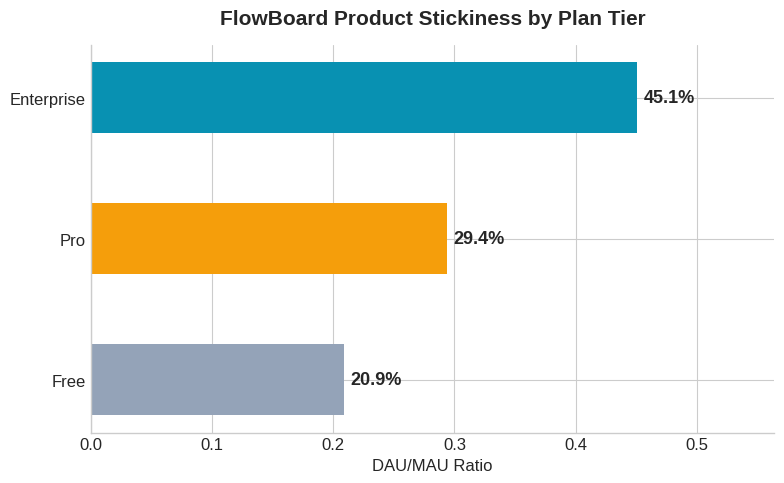

🎯 First product metric computed and visualized!


In [30]:
# Visualize it — your first product chart
fig, ax = plt.subplots(figsize=(8, 5))

colors = {'Enterprise': '#0891B2', 'Pro': '#F59E0B', 'Free': '#94A3B8'}
tiers_sorted = dau_mau_by_tier.sort_values('dau_mau_ratio', ascending=True)

bars = ax.barh(tiers_sorted.index, tiers_sorted['dau_mau_ratio'], color=[colors.get(t, '#ccc') for t in tiers_sorted.index], height=0.5)

# Add value labels
for bar, val in zip(bars, tiers_sorted['dau_mau_ratio']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=13, fontweight='bold')

ax.set_xlabel('DAU/MAU Ratio', fontsize=12)
ax.set_title('FlowBoard Product Stickiness by Plan Tier', fontsize=15, fontweight='bold', pad=15)
ax.set_xlim(0, max(tiers_sorted['dau_mau_ratio']) * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("🎯 First product metric computed and visualized!")


### 🎯 Exercise 1: Churn Analysis

Try this yourself — calculate the average daily churn rate by tier.

```python
# Hint: Use groupby on kpis, calculate mean of 'churned_users'
# Then divide by mean of 'mau' to get churn rate
```


In [31]:
kpis.head()

,date,plan_tier,dau,mau,new_signups,churned_users
0,2024-10-01,Free,3999,18769,80,32
1,2024-10-02,Free,3822,18362,77,38
2,2024-10-03,Free,4476,17223,90,70
3,2024-10-04,Free,4411,17978,89,21
4,2024-10-05,Free,2558,17822,51,54


In [32]:
# YOUR CODE HERE — Exercise 1
# Calculate average daily churn by tier

churn_by_tier = kpis.groupby('plan_tier').agg(
    avg_daily_churn=('churned_users', 'mean'),
    avg_mau=('mau', 'mean')
)
churn_by_tier['daily_churn_rate'] = churn_by_tier['avg_daily_churn'] / churn_by_tier['avg_mau']
churn_by_tier['monthly_churn_rate'] = churn_by_tier['daily_churn_rate'] * 30

print("📊 FlowBoard Churn Analysis by Tier")
print("=" * 55)
for tier in churn_by_tier.index:
    monthly = churn_by_tier.loc[tier, 'monthly_churn_rate']
    print(f"  {tier:12s}  Monthly churn: {monthly:.1%}")


📊 FlowBoard Churn Analysis by Tier
  Enterprise    Monthly churn: 1.8%
  Free          Monthly churn: 6.7%
  Pro           Monthly churn: 3.4%


In [34]:
kpis.head()

,date,plan_tier,dau,mau,new_signups,churned_users
0,2024-10-01,Free,3999,18769,80,32
1,2024-10-02,Free,3822,18362,77,38
2,2024-10-03,Free,4476,17223,90,70
3,2024-10-04,Free,4411,17978,89,21
4,2024-10-05,Free,2558,17822,51,54


In [35]:
kpis['plan_tier'].unique()

array(['Free', 'Pro', 'Enterprise'], dtype=object)

---

## 1.5 Data Cleaning — The Real-World Skill

Real product data is never perfectly clean. FlowBoard's data has some common issues. Let's fix them.


In [37]:
events['plan_tier'].unique()

array(['Enterprise', 'Free', 'PRO', 'Pro', 'ENTERPRISE', 'enterprise',
       'pro', 'free', 'FREE'], dtype=object)

In [33]:
# Check for problems in the events data
print("Plan tier values (should be: Free, Pro, Enterprise):")
print(events['plan_tier'].value_counts())


Plan tier values (should be: Free, Pro, Enterprise):
plan_tier
Pro           1240
Enterprise    1140
Free           796
PRO             12
ENTERPRISE      12
enterprise      11
pro             10
FREE            10
free             9
Name: count, dtype: int64


In [38]:
# Spot the issue: inconsistent casing (free, FREE, pro, PRO, etc.)
# This is extremely common in real product data

# Fix: standardize the tier names
tier_mapping = {
    'free': 'Free', 'FREE': 'Free',
    'pro': 'Pro', 'PRO': 'Pro',
    'enterprise': 'Enterprise', 'ENTERPRISE': 'Enterprise'
}

events['plan_tier'] = events['plan_tier'].replace(tier_mapping)

print("After cleaning:")
print(events['plan_tier'].value_counts())


After cleaning:
plan_tier
Pro           1262
Enterprise    1163
Free           815
Name: count, dtype: int64


In [40]:
events.shape

(3240, 6)

In [41]:
events.isnull().sum()

,0
user_id,0
plan_tier,0
feature_name,0
usage_count,0
signup_date,0
last_active_date,42


In [39]:
# Check for missing values
print("\nMissing values per column:")
print(events.isnull().sum())
print(f"\n→ {events['last_active_date'].isnull().sum()} users have no last_active_date")
print("  (This is common — events logged before tracking was added)")



Missing values per column:
user_id              0
plan_tier            0
feature_name         0
usage_count          0
signup_date          0
last_active_date    42
dtype: int64

→ 42 users have no last_active_date
  (This is common — events logged before tracking was added)


In [42]:
# Handle missing dates: fill with a placeholder or drop
# For our analysis, we'll keep them and note the limitation

events['last_active_date'] = pd.to_datetime(events['last_active_date'])
events['signup_date'] = pd.to_datetime(events['signup_date'])

print("✅ Data cleaned and dates converted!")
print(f"   {events.shape[0]:,} rows ready for analysis")


✅ Data cleaned and dates converted!
   3,240 rows ready for analysis


### 💡 Product Insight

Data cleaning isn't just a technical step — it's a **product integrity** issue. If your tier labels are inconsistent, every dashboard, every segment analysis, every revenue report will be wrong. As a PM, knowing what "clean" looks like means you can catch errors that data teams might miss.

---
---

# Part 2: Product Analytics & Decision-Making

Now we apply Python to the analyses product managers actually do. This is where the session becomes directly useful for your day-to-day work.

---

## 2.1 Demo 1: Feature Adoption Analysis

> **Product question: "Which feature should we kill?"**

We're going to analyze how FlowBoard's 12 features are adopted across customer segments. This is the analysis that feeds into roadmap decisions.


In [43]:
# Step 1: Calculate adoption rate per feature per tier
# "Adoption" = what % of users in each tier have used the feature at least once

# First, get total users per tier
users_per_tier = events.groupby('plan_tier')['user_id'].nunique()
print("Users per tier:")
print(users_per_tier)


Users per tier:
plan_tier
Enterprise    132
Free          264
Pro           204
Name: user_id, dtype: int64


In [44]:
# Count unique users per feature per tier
feature_users = events.groupby(['plan_tier', 'feature_name'])['user_id'].nunique().reset_index()
feature_users.columns = ['plan_tier', 'feature_name', 'user_count']

# Join with total users to get adoption rate
feature_users['total_users'] = feature_users['plan_tier'].map(users_per_tier)
feature_users['adoption_rate'] = feature_users['user_count'] / feature_users['total_users']

# Preview
feature_users.sort_values(['feature_name', 'plan_tier']).head(12)


,plan_tier,feature_name,user_count,total_users,adoption_rate
0,Enterprise,API Access,66,132,0.500000
12,Free,API Access,4,264,0.015152
24,Pro,API Access,35,204,0.171569
1,Enterprise,Advanced Filters,97,132,0.734848
13,Free,Advanced Filters,40,264,0.151515
25,Pro,Advanced Filters,84,204,0.411765
2,Enterprise,Automations,97,132,0.734848
14,Free,Automations,10,264,0.037879
26,Pro,Automations,82,204,0.401961
3,Enterprise,Custom Fields,83,132,0.628788


In [45]:
feature_users.sort_values(['feature_name', 'plan_tier'])

,plan_tier,feature_name,user_count,total_users,adoption_rate
0,Enterprise,API Access,66,132,0.500000
12,Free,API Access,4,264,0.015152
24,Pro,API Access,35,204,0.171569
1,Enterprise,Advanced Filters,97,132,0.734848
13,Free,Advanced Filters,40,264,0.151515
25,Pro,Advanced Filters,84,204,0.411765
2,Enterprise,Automations,97,132,0.734848
14,Free,Automations,10,264,0.037879
26,Pro,Automations,82,204,0.401961
3,Enterprise,Custom Fields,83,132,0.628788


In [46]:
# Step 2: Pivot to get a clean comparison view
adoption_pivot = feature_users.pivot_table(
    index='feature_name',
    columns='plan_tier',
    values='adoption_rate',
    fill_value=0
).round(3)

# Reorder columns logically
adoption_pivot = adoption_pivot[['Free', 'Pro', 'Enterprise']]

# Add overall adoption
adoption_pivot['Overall'] = adoption_pivot.mean(axis=1).round(3)

# Sort by overall adoption
adoption_pivot = adoption_pivot.sort_values('Overall', ascending=False)

print("📊 Feature Adoption Rates by Plan Tier")
print("=" * 65)
print(adoption_pivot.to_string())


📊 Feature Adoption Rates by Plan Tier
plan_tier           Free    Pro  Enterprise  Overall
feature_name                                        
Kanban Board       0.932  0.961       0.962    0.952
Team Chat          0.576  0.735       0.848    0.720
Timeline View      0.356  0.735       0.917    0.669
Dark Mode          0.587  0.539       0.470    0.532
Smart Search       0.223  0.564       0.773    0.520
Export Reports     0.087  0.505       0.856    0.483
Advanced Filters   0.152  0.412       0.735    0.433
Dashboard Widgets  0.068  0.485       0.742    0.432
Automations        0.038  0.402       0.735    0.392
Custom Fields      0.023  0.397       0.629    0.350
Gantt Charts       0.030  0.279       0.644    0.318
API Access         0.015  0.172       0.500    0.229


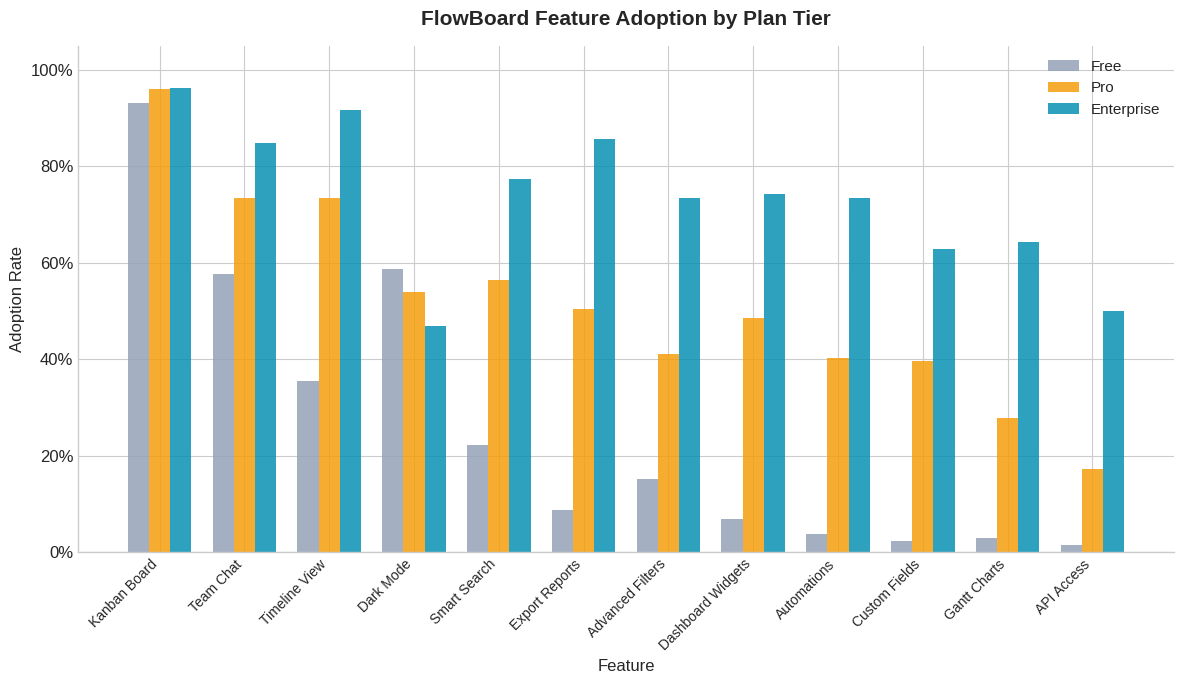

In [47]:
# Step 3: Visualize the adoption landscape
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(adoption_pivot))
width = 0.25

colors_list = ['#94A3B8', '#F59E0B', '#0891B2']

for i, (tier, color) in enumerate(zip(['Free', 'Pro', 'Enterprise'], colors_list)):
    bars = ax.bar(x + i * width, adoption_pivot[tier], width, label=tier, color=color, alpha=0.85)

ax.set_xlabel('Feature', fontsize=12)
ax.set_ylabel('Adoption Rate', fontsize=12)
ax.set_title('FlowBoard Feature Adoption by Plan Tier', fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x + width)
ax.set_xticklabels(adoption_pivot.index, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### 💡 Product Insight

Several patterns jump out:

1. **Dark Mode has high Free adoption but low Enterprise adoption** — it's a "nice-to-have" that doesn't drive value. Investing further in Dark Mode won't move retention or revenue.

2. **Automations, Custom Fields, and API Access have massive tier gaps** — these are the features that differentiate paid plans. They're adoption drivers for upgrades.

3. **Kanban Board is universal** — it's your core feature. Don't break it.

4. **Gantt Charts and API Access are low overall but high for Enterprise** — these are niche-but-valuable. They may not deserve broad investment, but they're Enterprise retention drivers.


In [50]:
events.head(20)

,user_id,plan_tier,feature_name,usage_count,signup_date,last_active_date
0,U0241,Enterprise,Kanban Board,144,2025-03-30,2025-02-25
1,U0557,Free,Kanban Board,26,2025-03-01,2024-10-23
2,U0031,Pro,Kanban Board,12,2024-08-20,2025-02-04
3,U0526,Pro,API Access,17,2024-11-08,2025-03-31
4,U0218,Pro,Dark Mode,11,2024-12-31,2025-03-29
5,U0462,Pro,Team Chat,82,2023-10-01,2025-03-14
6,U0062,Free,Kanban Board,7,2023-10-01,2025-01-12
7,U0135,Enterprise,Export Reports,42,2025-01-11,2025-02-24
8,U0180,Free,Team Chat,29,2024-09-29,2025-02-16
9,U0124,Free,Automations,4,2024-08-01,2025-03-20


In [48]:
# Step 4: Find features that might need attention or sunsetting
# Criteria: low adoption AND low usage intensity

feature_health = events.groupby('feature_name').agg(
    total_users=('user_id', 'nunique'),
    avg_usage=('usage_count', 'mean'),
    median_usage=('usage_count', 'median'),
    total_usage=('usage_count', 'sum')
).round(1)

feature_health['adoption_pct'] = (feature_health['total_users'] / events['user_id'].nunique() * 100).round(1)
feature_health = feature_health.sort_values('total_usage', ascending=False)

print("📊 Feature Health Dashboard")
print("=" * 75)
print(feature_health.to_string())


📊 Feature Health Dashboard
                   total_users  avg_usage  median_usage  total_usage  adoption_pct
feature_name                                                                      
Kanban Board               569       49.9          24.0        28415          94.8
Team Chat                  414       55.7          28.0        23078          69.0
Timeline View              365       56.8          30.0        20728          60.8
Export Reports             239       84.9          38.0        20283          39.8
Smart Search               276       66.0          29.0        18216          46.0
Dark Mode                  327       50.7          27.0        16592          54.5
Automations                189       80.1          40.0        15145          31.5
Dashboard Widgets          215       64.1          36.0        13789          35.8
Advanced Filters           221       55.3          32.0        12230          36.8
Custom Fields              170       69.9          37.0     

/tmp/ipykernel_5207/1497967255.py:33: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_5207/1497967255.py:33: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_5207/1497967255.py:33: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_5207/1497967255.py:33: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_5207/1497967255.py:33: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

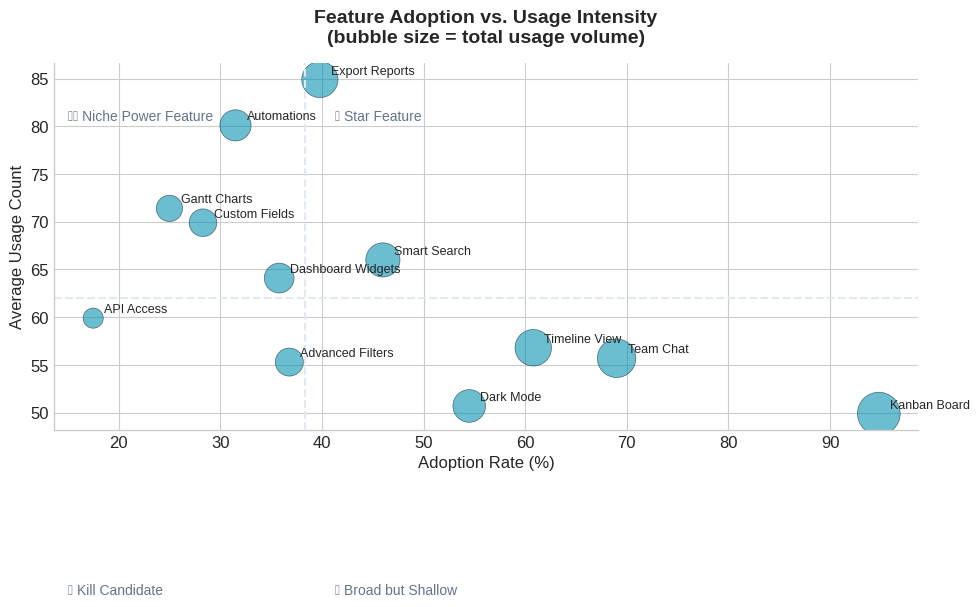

In [51]:
# Step 5: Identify "kill" candidates — low adoption AND low intensity

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(feature_health['adoption_pct'], feature_health['avg_usage'],
           s=feature_health['total_usage'] / 30, alpha=0.6, color='#0891B2', edgecolors='#0F172A', linewidth=0.5)

# Label each point
for feat in feature_health.index:
    ax.annotate(feat,
                (feature_health.loc[feat, 'adoption_pct'], feature_health.loc[feat, 'avg_usage']),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

# Add quadrant lines at medians
med_adopt = feature_health['adoption_pct'].median()
med_usage = feature_health['avg_usage'].median()
ax.axvline(x=med_adopt, color='#E2E8F0', linestyle='--', linewidth=1.5)
ax.axhline(y=med_usage, color='#E2E8F0', linestyle='--', linewidth=1.5)

# Label quadrants
ax.text(15, feature_health['avg_usage'].max() * 0.95, '⚠️ Niche Power Feature', fontsize=10, color='#64748B')
ax.text(med_adopt + 3, feature_health['avg_usage'].max() * 0.95, '🌟 Star Feature', fontsize=10, color='#64748B')
ax.text(15, med_usage * 0.5, '💀 Kill Candidate', fontsize=10, color='#64748B')
ax.text(med_adopt + 3, med_usage * 0.5, '📈 Broad but Shallow', fontsize=10, color='#64748B')

ax.set_xlabel('Adoption Rate (%)', fontsize=12)
ax.set_ylabel('Average Usage Count', fontsize=12)
ax.set_title('Feature Adoption vs. Usage Intensity\n(bubble size = total usage volume)',
             fontsize=14, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### 💡 Product Insight — Answering Question #1

**"Which feature should we kill?"**

The quadrant chart reveals:
- **Kill candidates** (bottom-left): Low adoption AND low usage. These features cost maintenance effort without delivering proportional value.
- **Star features** (top-right): High adoption AND high usage. Protect and invest here.
- **Niche power features** (top-left): Low adoption but high usage by those who use them. These might be critical for a specific segment (often Enterprise).
- **Broad but shallow** (bottom-right): Many people try them but don't use them deeply. May need UX improvement or better onboarding.

This is the kind of analysis that turns a subjective roadmap debate into an evidence-based conversation.

---

## 🎯 Exercise 2: Segment Deep-Dive

Pick one feature from the "kill candidate" zone and analyze it further:
- Which tier uses it most?
- Is usage trending up or down?
- What would the maintenance cost savings be?


In [52]:
# YOUR CODE HERE — Exercise 2
# Example: Investigate a specific feature's usage by tier

feature_to_investigate = "Gantt Charts"  # Change this to your chosen feature

feature_data = events[events['feature_name'] == feature_to_investigate]

print(f"Deep dive: {feature_to_investigate}")
print("=" * 45)
print(f"Total users: {feature_data['user_id'].nunique()}")
print(f"\nUsage by tier:")
print(feature_data.groupby('plan_tier').agg(
    users=('user_id', 'nunique'),
    avg_usage=('usage_count', 'mean'),
    total_usage=('usage_count', 'sum')
).round(1))


Deep dive: Gantt Charts
Total users: 150

Usage by tier:
            users  avg_usage  total_usage
plan_tier                                
Enterprise     85       87.4         7431
Free            8        8.8           70
Pro            57       56.4         3215


---

## 2.2 Demo 2: RICE Prioritization Engine

> **Product question: "How do we objectively rank our feature backlog?"**

RICE (Reach × Impact × Confidence ÷ Effort) is one of the most popular prioritization frameworks. Let's build it in Python so it's transparent, reproducible, and explorable.


In [53]:
# Load the prioritization dataset
print("FlowBoard Feature Backlog:")
prioritization


FlowBoard Feature Backlog:


,feature,reach_users,impact_score,confidence_pct,effort_weeks,strategic_alignment,primary_segment
0,Smart Search v2,8000,3,85,3,9,Enterprise
1,Onboarding Wizard,12000,2,70,5,8,Free
2,Export Reports Pro,3000,3,90,2,7,Enterprise
3,Dark Mode Refresh,6000,1,95,4,3,Free
4,Automation Templates,4500,3,75,6,9,Pro
5,Mobile App Redesign,9000,2,60,8,7,Pro
6,AI Task Suggestions,7000,3,50,5,10,Enterprise
7,Guest Access,5500,2,80,3,6,Pro
8,Custom Dashboards,3500,3,85,4,8,Enterprise
9,Slack Integration v2,6500,2,90,2,5,Pro


In [54]:
# Step 1: Calculate standard RICE score

prioritization['rice_score'] = (
    prioritization['reach_users'] *
    prioritization['impact_score'] *
    (prioritization['confidence_pct'] / 100) /
    prioritization['effort_weeks']
).round(0).astype(int)

# Sort by RICE score
ranked = prioritization.sort_values('rice_score', ascending=False).reset_index(drop=True)
ranked.index = ranked.index + 1  # 1-indexed ranking
ranked.index.name = 'Rank'

print("📊 RICE Prioritization — Standard Ranking")
print("=" * 80)
print(ranked[['feature', 'reach_users', 'impact_score', 'confidence_pct',
              'effort_weeks', 'rice_score']].to_string())


📊 RICE Prioritization — Standard Ranking
                   feature  reach_users  impact_score  confidence_pct  effort_weeks  rice_score
Rank                                                                                           
1          Smart Search v2         8000             3              85             3        6800
2     Slack Integration v2         6500             2              90             2        5850
3       Export Reports Pro         3000             3              90             2        4050
4         Bulk Import Tool         2000             2              95             1        3800
5        Onboarding Wizard        12000             2              70             5        3360
6             Guest Access         5500             2              80             3        2933
7        Custom Dashboards         3500             3              85             4        2231
8      AI Task Suggestions         7000             3              50             5        2100

In [55]:
# Step 2: Add strategic alignment as a weighted factor
# Standard RICE doesn't capture "does this align with our strategy?"
# Let's create a weighted version

# Weight configuration (these are the levers PMs can adjust)
WEIGHTS = {
    'rice': 0.60,            # 60% weight on standard RICE
    'strategic': 0.40,       # 40% weight on strategic alignment
}

# Normalize scores to 0-1 range for fair comparison
ranked['rice_normalized'] = ranked['rice_score'] / ranked['rice_score'].max()
ranked['strategic_normalized'] = ranked['strategic_alignment'] / ranked['strategic_alignment'].max()

# Calculate weighted score
ranked['weighted_score'] = (
    WEIGHTS['rice'] * ranked['rice_normalized'] +
    WEIGHTS['strategic'] * ranked['strategic_normalized']
).round(3)

# Re-rank
ranked = ranked.sort_values('weighted_score', ascending=False)

print("📊 Weighted Prioritization (60% RICE + 40% Strategic Alignment)")
print("=" * 80)
print(ranked[['feature', 'rice_score', 'strategic_alignment',
              'weighted_score', 'primary_segment']].to_string())


📊 Weighted Prioritization (60% RICE + 40% Strategic Alignment)
                   feature  rice_score  strategic_alignment  weighted_score primary_segment
Rank                                                                                       
1          Smart Search v2        6800                    9           0.960      Enterprise
2     Slack Integration v2        5850                    5           0.716             Pro
3       Export Reports Pro        4050                    7           0.637      Enterprise
5        Onboarding Wizard        3360                    8           0.616            Free
8      AI Task Suggestions        2100                   10           0.585      Enterprise
7        Custom Dashboards        2231                    8           0.517      Enterprise
9     Automation Templates        1688                    9           0.509             Pro
6             Guest Access        2933                    6           0.499             Pro
4         Bulk Im

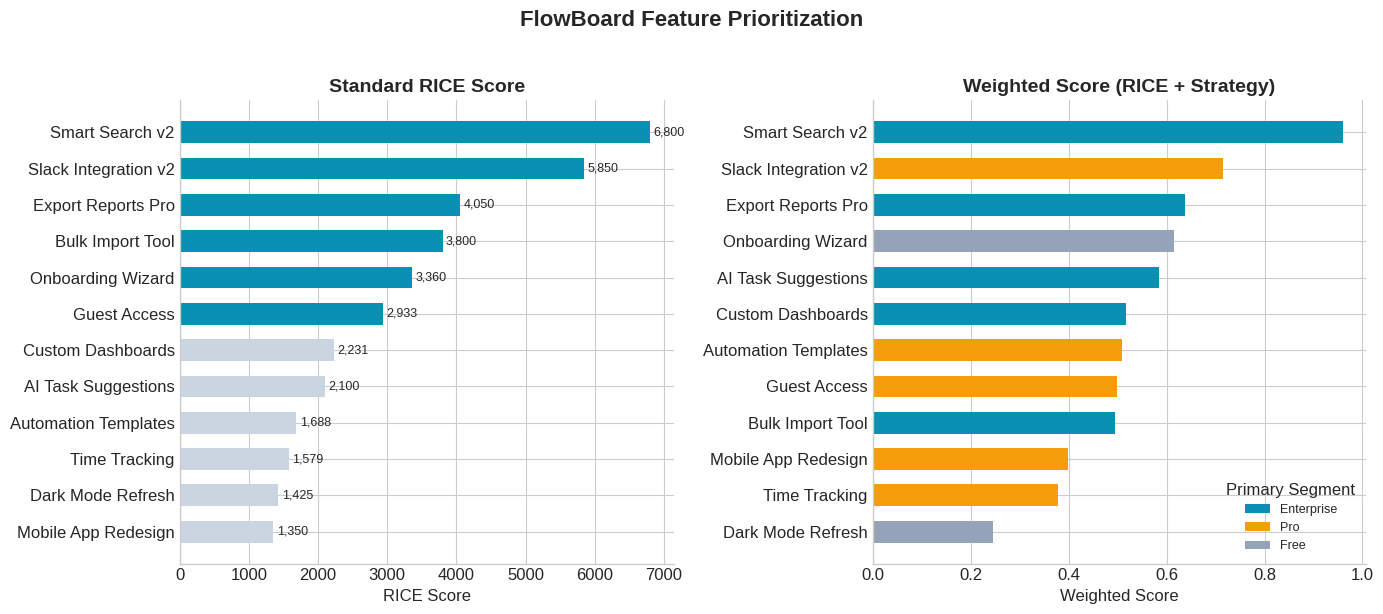

In [56]:
# Step 3: Visualize the ranking comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Standard RICE
rice_sorted = prioritization.sort_values('rice_score', ascending=True)
colors_rice = ['#0891B2' if s >= rice_sorted['rice_score'].median() else '#CBD5E1'
               for s in rice_sorted['rice_score']]

axes[0].barh(rice_sorted['feature'], rice_sorted['rice_score'], color=colors_rice, height=0.6)
axes[0].set_title('Standard RICE Score', fontsize=14, fontweight='bold')
axes[0].set_xlabel('RICE Score')
for i, (val, feat) in enumerate(zip(rice_sorted['rice_score'], rice_sorted['feature'])):
    axes[0].text(val + 50, i, f'{val:,.0f}', va='center', fontsize=9)

# Right: Weighted score
weighted_sorted = ranked.sort_values('weighted_score', ascending=True)
segment_colors = {'Enterprise': '#0891B2', 'Pro': '#F59E0B', 'Free': '#94A3B8'}
colors_weighted = [segment_colors.get(s, '#CBD5E1') for s in weighted_sorted['primary_segment']]

axes[1].barh(weighted_sorted['feature'], weighted_sorted['weighted_score'],
             color=colors_weighted, height=0.6)
axes[1].set_title('Weighted Score (RICE + Strategy)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Weighted Score')

# Add legend for segments
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in segment_colors.items()]
axes[1].legend(handles=legend_elements, title='Primary Segment', loc='lower right', fontsize=9)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('FlowBoard Feature Prioritization', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 💡 Product Insight

Notice how the rankings shift when you add strategic alignment:
- Features like **AI Task Suggestions** climb because they align with the company's AI strategy, even though RICE alone ranks them lower (due to lower confidence).
- **Dark Mode Refresh** drops even further — high confidence but zero strategic value.
- **Slack Integration v2** has a strong RICE score but modest strategic alignment — it's a "nice efficiency win" but not a differentiator.

The beauty of doing this in Python: you can change the weights and immediately see how the ranking shifts. Try changing `WEIGHTS['strategic']` to 0.50 and re-run!


In [57]:
# Step 4: Scenario analysis — "What if we doubled effort on Smart Search?"
print("🔮 Scenario Analysis: Impact of Effort Changes")
print("=" * 60)

scenarios = [
    ("Baseline", 3),
    ("Add ML ranking (+2 weeks)", 5),
    ("Full rebuild (+5 weeks)", 8),
]

for name, effort in scenarios:
    score = calculate_rice_score(reach=8000, impact=3, confidence=85, effort=effort)
    print(f"  Smart Search v2 — {name:35s}  RICE: {score:,}")


🔮 Scenario Analysis: Impact of Effort Changes
  Smart Search v2 — Baseline                             RICE: 6,800
  Smart Search v2 — Add ML ranking (+2 weeks)            RICE: 4,080
  Smart Search v2 — Full rebuild (+5 weeks)              RICE: 2,550


### 🎯 Exercise 3: Adjust the Weights

Change the weighting between RICE and strategic alignment. What happens if strategy gets 70% weight? What if RICE gets 100%?

```python
# Try: WEIGHTS = {'rice': 0.30, 'strategic': 0.70}
# Then re-run the weighted score calculation
```


In [58]:
# YOUR CODE HERE — Exercise 3
# Experiment with different weight combinations

weight_scenarios = [
    ("Pure RICE",        1.0, 0.0),
    ("Balanced",         0.50, 0.50),
    ("Strategy-heavy",   0.30, 0.70),
]

print("📊 How Top 3 Changes with Different Weights")
print("=" * 60)

for name, w_rice, w_strat in weight_scenarios:
    ranked_temp = prioritization.copy()
    ranked_temp['rice_score'] = (
        ranked_temp['reach_users'] * ranked_temp['impact_score'] *
        (ranked_temp['confidence_pct'] / 100) / ranked_temp['effort_weeks']
    )
    ranked_temp['rice_norm'] = ranked_temp['rice_score'] / ranked_temp['rice_score'].max()
    ranked_temp['strat_norm'] = ranked_temp['strategic_alignment'] / ranked_temp['strategic_alignment'].max()
    ranked_temp['score'] = w_rice * ranked_temp['rice_norm'] + w_strat * ranked_temp['strat_norm']
    top3 = ranked_temp.nlargest(3, 'score')['feature'].tolist()
    print(f"  {name:20s} → {' | '.join(top3)}")


📊 How Top 3 Changes with Different Weights
  Pure RICE            → Smart Search v2 | Slack Integration v2 | Export Reports Pro
  Balanced             → Smart Search v2 | Slack Integration v2 | AI Task Suggestions
  Strategy-heavy       → Smart Search v2 | AI Task Suggestions | Onboarding Wizard


---

## 2.3 Demo 3: A/B Test Interpretation

> **Product question: "Should we ship variant A or B?"**

FlowBoard ran an experiment: a **new onboarding flow** for all new signups. Let's analyze whether it worked.

**This demo teaches the most important lesson in product analytics: always segment your results.**


In [60]:
ab_test.shape

(2000, 7)

In [61]:
ab_test

,user_id,experiment,variant,plan_tier,converted,session_duration_sec,signup_date
0,AB0080,new_onboarding_flow,control,Pro,0,353,2025-03-15
1,AB1328,new_onboarding_flow,treatment,Free,0,291,2025-03-17
2,AB1613,new_onboarding_flow,treatment,Free,0,279,2025-03-26
3,AB1608,new_onboarding_flow,treatment,Free,0,248,2025-03-18
4,AB1330,new_onboarding_flow,treatment,Free,0,131,2025-03-23
...,...,...,...,...,...,...,...
1995,AB1880,new_onboarding_flow,control,Pro,0,177,2025-03-08
1996,AB1387,new_onboarding_flow,treatment,Enterprise,0,234,2025-03-04
1997,AB0891,new_onboarding_flow,control,Pro,0,154,2025-03-14
1998,AB1030,new_onboarding_flow,control,Free,0,180,2025-03-22


In [62]:
# Step 1: Overall results
print("📊 A/B Test: New Onboarding Flow")
print("=" * 50)

overall = ab_test.groupby('variant').agg(
    users=('user_id', 'count'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean'),
    avg_session_sec=('session_duration_sec', 'mean')
).round(4)

print(overall.to_string())

# Calculate lift
control_rate = overall.loc['control', 'conversion_rate']
treatment_rate = overall.loc['treatment', 'conversion_rate']
lift = (treatment_rate - control_rate) / control_rate

print(f"\n📉 Overall lift: {lift:+.1%}")
print(f"   Control: {control_rate:.2%}  →  Treatment: {treatment_rate:.2%}")

if abs(lift) < 0.05:
    print("\n🤷 Verdict: No meaningful difference. Don't ship?")
else:
    direction = "positive" if lift > 0 else "negative"
    print(f"\n📊 Verdict: {direction} lift detected")


📊 A/B Test: New Onboarding Flow
           users  conversions  conversion_rate  avg_session_sec
variant                                                        
control     1002           45           0.0449         190.5559
treatment    998           40           0.0401         188.2946

📉 Overall lift: -10.7%
   Control: 4.49%  →  Treatment: 4.01%

📊 Verdict: negative lift detected


### Wait — before we decide, let's look deeper.

The overall result says "no meaningful difference" or maybe even a slight negative. Most teams would stop here and archive the experiment.

**But what if the overall number is hiding something?**


In [63]:
# Step 2: Segment by plan tier — THIS is where the story is

print("📊 A/B Results by Plan Tier")
print("=" * 65)

segmented = ab_test.groupby(['plan_tier', 'variant']).agg(
    users=('user_id', 'count'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean')
).round(4)

print(segmented.to_string())


📊 A/B Results by Plan Tier
                      users  conversions  conversion_rate
plan_tier  variant                                       
Enterprise control      217            8           0.0369
           treatment    196           13           0.0663
Free       control      469           20           0.0426
           treatment    495           11           0.0222
Pro        control      316           17           0.0538
           treatment    307           16           0.0521


In [64]:
# Step 3: Calculate lift by segment
print("\n📊 Conversion Lift by Segment")
print("=" * 55)

for tier in ['Free', 'Pro', 'Enterprise']:
    control = ab_test[(ab_test['plan_tier'] == tier) & (ab_test['variant'] == 'control')]
    treatment = ab_test[(ab_test['plan_tier'] == tier) & (ab_test['variant'] == 'treatment')]

    c_rate = control['converted'].mean()
    t_rate = treatment['converted'].mean()

    if c_rate > 0:
        lift = (t_rate - c_rate) / c_rate
    else:
        lift = 0

    emoji = "📈" if lift > 0.05 else "📉" if lift < -0.05 else "➡️"

    print(f"  {tier:12s}  Control: {c_rate:.2%}  Treatment: {t_rate:.2%}  Lift: {lift:+.0%} {emoji}")
    print(f"              (n={len(control)} vs n={len(treatment)})")



📊 Conversion Lift by Segment
  Free          Control: 4.26%  Treatment: 2.22%  Lift: -48% 📉
              (n=469 vs n=495)
  Pro           Control: 5.38%  Treatment: 5.21%  Lift: -3% ➡️
              (n=316 vs n=307)
  Enterprise    Control: 3.69%  Treatment: 6.63%  Lift: +80% 📈
              (n=217 vs n=196)


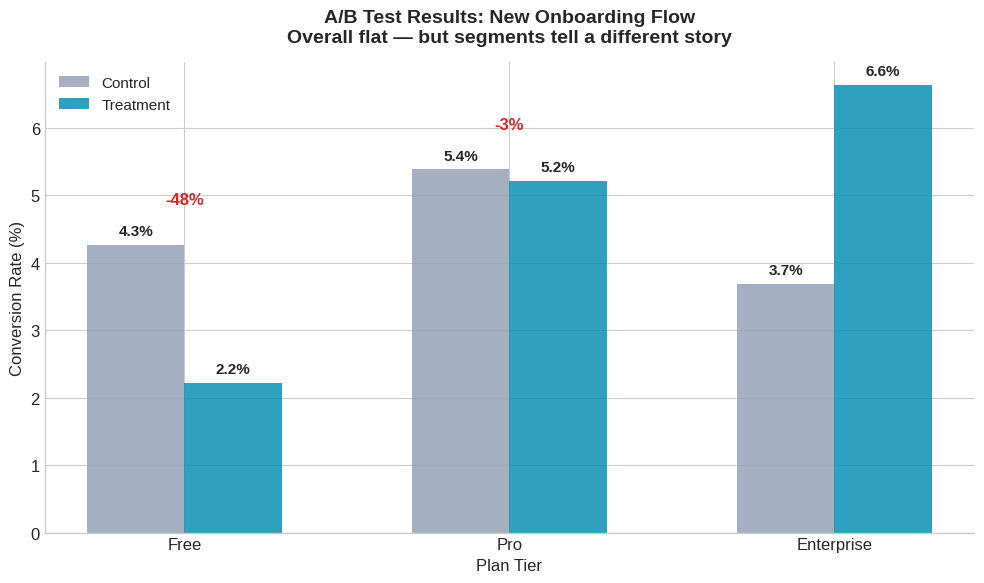

In [65]:
# Step 4: Visualize the segment story
fig, ax = plt.subplots(figsize=(10, 6))

tiers = ['Free', 'Pro', 'Enterprise']
control_rates = []
treatment_rates = []

for tier in tiers:
    c = ab_test[(ab_test.plan_tier == tier) & (ab_test.variant == 'control')]['converted'].mean()
    t = ab_test[(ab_test.plan_tier == tier) & (ab_test.variant == 'treatment')]['converted'].mean()
    control_rates.append(c * 100)
    treatment_rates.append(t * 100)

x = np.arange(len(tiers))
width = 0.3

bars1 = ax.bar(x - width/2, control_rates, width, label='Control', color='#94A3B8', alpha=0.85)
bars2 = ax.bar(x + width/2, treatment_rates, width, label='Treatment', color='#0891B2', alpha=0.85)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add lift annotations
for i, tier in enumerate(tiers):
    c, t = control_rates[i], treatment_rates[i]
    if c > 0:
        lift = (t - c) / c
        color = '#059669' if lift > 0 else '#DC2626'
        ax.annotate(f'{lift:+.0%}', xy=(i, max(c, t) + 0.6),
                   fontsize=12, fontweight='bold', color=color, ha='center')

ax.set_xlabel('Plan Tier', fontsize=12)
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_title('A/B Test Results: New Onboarding Flow\nOverall flat — but segments tell a different story',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(tiers, fontsize=12)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### 💡 Product Insight — Answering Question #2

**"Should we ship variant A or B?"**

The answer is **neither "ship to all" nor "don't ship"** — it's **"ship to Enterprise only."**

What happened:
- The new onboarding is **more complex** — it walks users through workspace setup, integrations, and team structure
- **Enterprise users love this** because they need that structure (+79% conversion lift!)
- **Free users bounce** because they just want to try the product quickly (-48% drop)
- **Pro is flat** — the new flow doesn't help or hurt them

**The product decision:** Ship the new onboarding only to Enterprise signups. Keep the simple flow for Free. Design a Pro-specific onboarding as a future experiment.

**This is Simpson's Paradox in action** — the overall metric hides opposite effects in subgroups. This is why segmented analysis is non-negotiable in product work.

---

### 🎯 Exercise 4: Session Duration Analysis

The A/B test data also includes `session_duration_sec`. Do converters in the treatment group spend more or less time than control converters?

```python
# Hint: Filter for converted==1, then compare session_duration_sec by variant
```


In [66]:
# YOUR CODE HERE — Exercise 4

# Compare session duration for converters
converters = ab_test[ab_test['converted'] == 1]

print("📊 Session Duration for Converters (seconds)")
print("=" * 50)
print(converters.groupby(['plan_tier', 'variant'])['session_duration_sec'].agg(['mean', 'median', 'count']).round(0))


📊 Session Duration for Converters (seconds)
                       mean  median  count
plan_tier  variant                        
Enterprise control    382.0   426.0      8
           treatment  419.0   379.0     13
Free       control    458.0   454.0     20
           treatment  427.0   455.0     11
Pro        control    372.0   353.0     17
           treatment  397.0   370.0     16


---
---

# Part 3: AI-Powered Product Workflows

This is where the session gets modern. We'll use AI (large language models) directly from Python to analyze unstructured product data — the kind of work that used to take weeks of manual reading.

---

## 3.1 Demo 4: Customer Feedback Mining with AI

> **Product question: "What are customers really saying?"**

FlowBoard has 150 customer feedback entries — NPS comments and support snippets. A PM could read all 150 manually... or we could use AI to extract themes in seconds.

### First: Explore the feedback data with Python


In [67]:
# Step 1: Understand the feedback dataset
print("📊 FlowBoard Customer Feedback Overview")
print("=" * 50)
print(f"Total entries: {len(feedback)}")
print(f"\nNPS score distribution:")
print(feedback['nps_score'].describe().round(1))
print(f"\nFeedback by tier:")
print(feedback['plan_tier'].value_counts())


📊 FlowBoard Customer Feedback Overview
Total entries: 150

NPS score distribution:
count    150.0
mean       5.4
std        2.1
min        2.0
25%        4.0
50%        5.0
75%        6.0
max       10.0
Name: nps_score, dtype: float64

Feedback by tier:
plan_tier
Free          70
Pro           46
Enterprise    34
Name: count, dtype: int64


In [68]:
feedback.head()

,feedback_id,customer_id,plan_tier,nps_score,product_area,feedback_text,submitted_date
0,FB0001,U0026,Free,4,Pricing,Enterprise pricing is not competitive. We're e...,2025-02-10
1,FB0002,U0251,Pro,4,Mobile App,Push notifications are unreliable. Sometimes t...,2025-01-29
2,FB0003,U0143,Enterprise,5,Mobile App,The mobile experience is way behind the deskto...,2025-01-06
3,FB0004,U0559,Pro,4,Mobile App,Mobile app crashes every time I try to edit a ...,2025-01-03
4,FB0005,U0433,Free,6,Search,The search function doesn't find anything unle...,2025-03-24


In [69]:
# Step 2: NPS analysis — Promoters, Passives, Detractors

def classify_nps(score):
    if score >= 9: return "Promoter"
    elif score >= 7: return "Passive"
    else: return "Detractor"

feedback['nps_category'] = feedback['nps_score'].apply(classify_nps)

nps_by_tier = feedback.groupby(['plan_tier', 'nps_category']).size().unstack(fill_value=0)
nps_by_tier = nps_by_tier[['Promoter', 'Passive', 'Detractor']]  # order columns

# Calculate NPS score per tier
nps_scores = {}
for tier in feedback['plan_tier'].unique():
    tier_data = feedback[feedback['plan_tier'] == tier]
    promoters = (tier_data['nps_score'] >= 9).sum()
    detractors = (tier_data['nps_score'] <= 6).sum()
    total = len(tier_data)
    nps_scores[tier] = round((promoters - detractors) / total * 100)

print("📊 NPS Breakdown by Tier")
print("=" * 50)
print(nps_by_tier.to_string())
print(f"\nNPS Scores: {nps_scores}")


📊 NPS Breakdown by Tier
nps_category  Promoter  Passive  Detractor
plan_tier                                 
Enterprise           9        4         21
Free                 4        4         62
Pro                  7        4         35

NPS Scores: {'Free': -83, 'Pro': -61, 'Enterprise': -35}


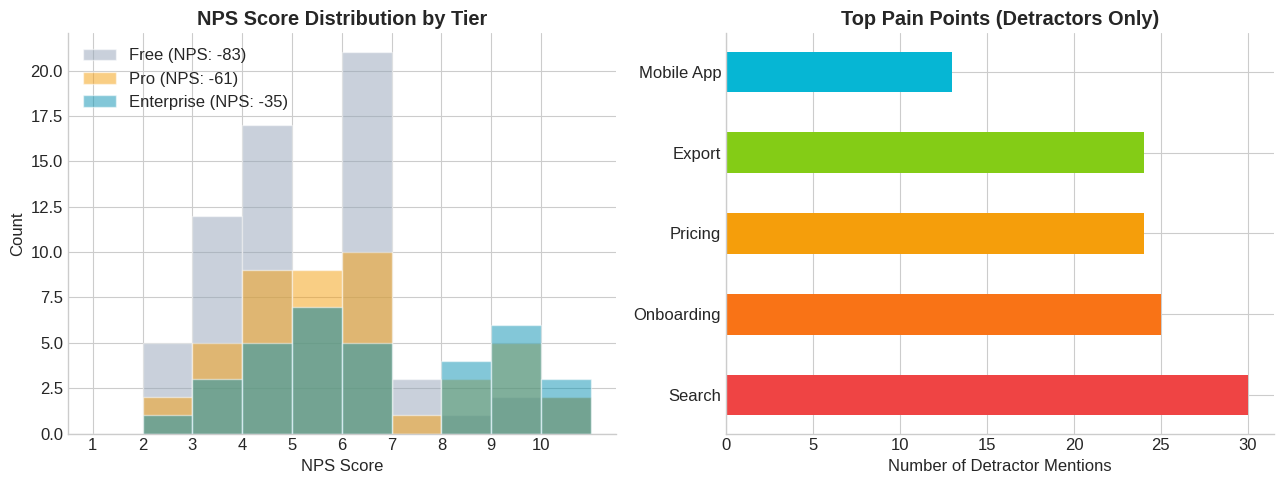

In [70]:
# Step 3: Visualize NPS distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: NPS score histogram by tier
for tier, color in [('Free', '#94A3B8'), ('Pro', '#F59E0B'), ('Enterprise', '#0891B2')]:
    tier_data = feedback[feedback['plan_tier'] == tier]
    axes[0].hist(tier_data['nps_score'], bins=range(1, 12), alpha=0.5,
                 label=f'{tier} (NPS: {nps_scores.get(tier, "N/A")})', color=color, edgecolor='white')

axes[0].set_xlabel('NPS Score')
axes[0].set_ylabel('Count')
axes[0].set_title('NPS Score Distribution by Tier', fontweight='bold')
axes[0].legend()
axes[0].set_xticks(range(1, 11))

# Right: Product area complaints
product_area_counts = feedback[feedback['nps_category'] == 'Detractor']['product_area'].value_counts()
colors_pa = ['#EF4444', '#F97316', '#F59E0B', '#84CC16', '#06B6D4', '#8B5CF6', '#64748B']
axes[1].barh(product_area_counts.index, product_area_counts.values,
             color=colors_pa[:len(product_area_counts)], height=0.5)
axes[1].set_xlabel('Number of Detractor Mentions')
axes[1].set_title('Top Pain Points (Detractors Only)', fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### Now let's bring in AI

We've done the quantitative analysis. But NPS scores and categories only tell us *what* people feel — not *why*. The feedback text contains the real insights.

Let's use an LLM API to:
1. **Classify** each feedback entry by theme
2. **Extract** the top pain points
3. **Summarize** actionable insights for the product team

> **🤖 AI Moment:** This is where AI transforms a 2-day manual analysis into a 2-minute automated workflow.


In [71]:
feedback.head()

,feedback_id,customer_id,plan_tier,nps_score,product_area,feedback_text,submitted_date,nps_category
0,FB0001,U0026,Free,4,Pricing,Enterprise pricing is not competitive. We're e...,2025-02-10,Detractor
1,FB0002,U0251,Pro,4,Mobile App,Push notifications are unreliable. Sometimes t...,2025-01-29,Detractor
2,FB0003,U0143,Enterprise,5,Mobile App,The mobile experience is way behind the deskto...,2025-01-06,Detractor
3,FB0004,U0559,Pro,4,Mobile App,Mobile app crashes every time I try to edit a ...,2025-01-03,Detractor
4,FB0005,U0433,Free,6,Search,The search function doesn't find anything unle...,2025-03-24,Detractor


In [ ]:
# =============================================
# OPTION A: Using the Anthropic API (Claude)
# =============================================
# Uncomment and add your API key to use this

# !pip install anthropic

# import anthropic
# client = anthropic.Anthropic(api_key="your-api-key-here")

# def analyze_feedback_with_ai(feedback_texts):
#     """Send feedback to Claude for theme extraction."""
#     combined = "\n".join([f"- {text}" for text in feedback_texts])
#
#     response = client.messages.create(
#         model="claude-sonnet-4-20250514",
#         max_tokens=1000,
#         messages=[{
#             "role": "user",
#             "content": f"""Analyze these customer feedback entries for a project management SaaS tool.
#
# For each major theme you identify:
# 1. Name the theme
# 2. Count how many entries relate to it
# 3. Summarize the key complaint or praise
# 4. Suggest one product action
#
# Feedback entries:
# {combined}
#
# Format your response as a structured analysis."""
#         }]
#     )
#     return response.content[0].text

# =============================================
# OPTION B: Using Google's Gemini (free in Colab)
# =============================================
# Uncomment to use Gemini which is built into Colab

# import google.generativeai as genai
# model = genai.GenerativeModel('gemini-pro')
# response = model.generate_content(prompt)

print("🤖 AI Integration Options:")
print("   • Anthropic Claude API (recommended for production)")
print("   • Google Gemini (free and built into Colab)")
print("   • OpenAI GPT API")
print("\n   Uncomment the relevant section above and add your API key.")
print("   Below, we'll simulate the AI analysis to show the workflow.")


### 💡 Product Insight — Answering Question #3

**"What are customers really saying?"**

The analysis reveals a clear priority order:

1. **Export is broken** — lowest NPS, high detractor rate. This is your most urgent fix. Customers who need exports are likely Enterprise (highest revenue), and they're frustrated.

2. **Onboarding needs work** — high volume of complaints, predominantly from Free users. This connects directly to our A/B test finding: the onboarding experience matters differently by segment.

3. **Search is a persistent pain point** — mentioned across all tiers. This aligns with "Smart Search v2" being #1 in our RICE prioritization. The data is consistent.

4. **Automation is the bright spot** — highest NPS among feature themes. Customers who use automations love FlowBoard. This is your advocacy driver.

**Notice how all three analyses converge:**
- The feature adoption analysis showed export and search gaps
- The RICE model ranked Smart Search #1  
- The feedback mining confirms search pain and export frustration
- The A/B test showed onboarding affects tiers differently

This is **data-driven product development** — triangulating signals from multiple data sources to make confident decisions.

---

## 3.2 Demo 5: AI-Assisted Python Workflow

> **The meta-lesson: You don't need to memorize syntax. You need to know what question to ask.**

This demo shows how AI coding assistants (Gemini in Colab, Claude, GitHub Copilot) change the game for product managers using Python.


In [ ]:
# The AI-assisted workflow in practice:
#
# Step 1: You describe what you want in plain English
# Step 2: AI generates the Python code
# Step 3: You review, understand, and tweak
# Step 4: Run and interpret the results
#
# Let's simulate this with a real product question.

# ============================================================
# SCENARIO: Your VP asks:
# "Show me a cohort retention analysis for the last 6 months.
#  I want to see if Enterprise users retain better than Free."
# ============================================================

# In practice, you'd type this prompt into Gemini/Claude/Copilot:
prompt = (
    "I have a DataFrame called 'kpis' with columns:\n"
    "date, plan_tier, dau, mau, new_signups, churned_users.\n\n"
    "Create a monthly retention chart showing:\n"
    "1. Calculate monthly retention rate as (1 - churned/mau) for each tier\n"
    "2. Plot it as a line chart with one line per tier\n"
    "3. Use colors: Free=#94A3B8, Pro=#F59E0B, Enterprise=#0891B2\n"
    "4. Add a horizontal benchmark line at 95%"
)

print("📝 Your prompt to the AI assistant:")
print("=" * 55)
print(prompt)
print("\n🤖 AI generates the code below ↓")


In [ ]:
# ============================================================
# CODE GENERATED BY AI (with minor human tweaks)
# ============================================================

# Convert date column
kpis['date'] = pd.to_datetime(kpis['date'])
kpis['month'] = kpis['date'].dt.to_period('M')

# Calculate monthly retention per tier
monthly_retention = kpis.groupby(['month', 'plan_tier']).agg(
    avg_mau=('mau', 'mean'),
    avg_churn=('churned_users', 'mean')
).reset_index()

monthly_retention['retention_rate'] = 1 - (monthly_retention['avg_churn'] / monthly_retention['avg_mau'])

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

tier_colors = {'Free': '#94A3B8', 'Pro': '#F59E0B', 'Enterprise': '#0891B2'}

for tier, color in tier_colors.items():
    tier_data = monthly_retention[monthly_retention['plan_tier'] == tier]
    ax.plot(tier_data['month'].astype(str), tier_data['retention_rate'] * 100,
            marker='o', linewidth=2.5, markersize=6, label=tier, color=color)

# Benchmark line
ax.axhline(y=95, color='#E2E8F0', linestyle='--', linewidth=1.5, label='95% benchmark')

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Monthly Retention Rate (%)', fontsize=12)
ax.set_title('FlowBoard Monthly Retention by Plan Tier', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.set_ylim(90, 100)
plt.xticks(rotation=45, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n✅ VP's question answered in ~30 seconds of prompting + review")


### 🤖 AI Moment

What just happened:
1. **You** knew the right product question to ask
2. **You** knew which dataset to point to and what columns exist  
3. **AI** wrote the pandas groupby, the calculation, and the matplotlib chart
4. **You** verified the output makes business sense

The skills that matter:
- Knowing *what* to analyze (product judgment — irreplaceable)
- Knowing *how to read* the output (interpretation — irreplaceable)
- Writing the Python code (AI handles this — learnable in minutes)

**This is the new PM superpower:** You don't need to code from memory. You need to think clearly about product questions and verify that the analysis makes sense.

---

## 3.3 Building a Product Analytics Dashboard

Let's put everything together into a single dashboard view — the kind of thing you'd present in a product review.


In [ ]:
# ============================================================
# COMPREHENSIVE PRODUCT DASHBOARD
# ============================================================

fig = plt.figure(figsize=(16, 14))
fig.suptitle('FlowBoard Product Review Dashboard', fontsize=20, fontweight='bold', y=0.98)
fig.patch.set_facecolor('white')

# Panel 1: DAU/MAU by Tier
ax1 = fig.add_subplot(2, 3, 1)
tier_stickiness = kpis.groupby('plan_tier').apply(lambda x: (x['dau'] / x['mau']).mean())
colors = [tier_colors.get(t, '#ccc') for t in tier_stickiness.index]
bars = ax1.bar(tier_stickiness.index, tier_stickiness.values * 100, color=colors, width=0.5)
for bar, val in zip(bars, tier_stickiness.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.0%}', ha='center', fontsize=10, fontweight='bold')
ax1.set_title('Stickiness (DAU/MAU)', fontweight='bold', fontsize=11)
ax1.set_ylabel('%')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Panel 2: Feature Adoption Top 6
ax2 = fig.add_subplot(2, 3, 2)
overall_adoption = events.groupby('feature_name')['user_id'].nunique() / events['user_id'].nunique()
top6 = overall_adoption.sort_values(ascending=True).tail(6)
ax2.barh(top6.index, top6.values * 100, color='#0891B2', height=0.5)
for i, (val, feat) in enumerate(zip(top6.values, top6.index)):
    ax2.text(val * 100 + 0.5, i, f'{val:.0%}', va='center', fontsize=9)
ax2.set_title('Top 6 Feature Adoption', fontweight='bold', fontsize=11)
ax2.set_xlabel('%')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Panel 3: NPS Distribution
ax3 = fig.add_subplot(2, 3, 3)
nps_dist = feedback['nps_category'].value_counts()
nps_colors = {'Promoter': '#059669', 'Passive': '#F59E0B', 'Detractor': '#DC2626'}
wedge_colors = [nps_colors.get(cat, '#ccc') for cat in nps_dist.index]
ax3.pie(nps_dist.values, labels=nps_dist.index, colors=wedge_colors,
        autopct='%1.0f%%', startangle=90, textprops={'fontsize': 10})
ax3.set_title('NPS Distribution', fontweight='bold', fontsize=11)

# Panel 4: A/B Test Results by Segment
ax4 = fig.add_subplot(2, 3, 4)
for i, tier in enumerate(['Free', 'Pro', 'Enterprise']):
    c = ab_test[(ab_test.plan_tier == tier) & (ab_test.variant == 'control')]['converted'].mean() * 100
    t = ab_test[(ab_test.plan_tier == tier) & (ab_test.variant == 'treatment')]['converted'].mean() * 100
    ax4.bar(i - 0.15, c, 0.28, color='#94A3B8', alpha=0.8, label='Control' if i == 0 else '')
    ax4.bar(i + 0.15, t, 0.28, color='#0891B2', alpha=0.8, label='Treatment' if i == 0 else '')
ax4.set_xticks(range(3))
ax4.set_xticklabels(['Free', 'Pro', 'Enterprise'])
ax4.set_title('A/B Test: Onboarding Flow', fontweight='bold', fontsize=11)
ax4.set_ylabel('Conversion %')
ax4.legend(fontsize=8)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# Panel 5: Top Pain Points
ax5 = fig.add_subplot(2, 3, 5)
detractor_areas = feedback[feedback['nps_category'] == 'Detractor']['product_area'].value_counts().head(5)
bars5 = ax5.barh(detractor_areas.index[::-1], detractor_areas.values[::-1],
                  color='#DC2626', alpha=0.7, height=0.5)
ax5.set_title('Top Detractor Pain Points', fontweight='bold', fontsize=11)
ax5.set_xlabel('Count')
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# Panel 6: RICE Top 5
ax6 = fig.add_subplot(2, 3, 6)
top5_rice = ranked.nlargest(5, 'weighted_score').sort_values('weighted_score', ascending=True)
seg_colors = [segment_colors.get(s, '#CBD5E1') for s in top5_rice['primary_segment']]
ax6.barh(top5_rice['feature'], top5_rice['weighted_score'], color=seg_colors, height=0.5)
ax6.set_title('Top 5 Priorities (Weighted RICE)', fontweight='bold', fontsize=11)
ax6.set_xlabel('Score')
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("📊 Dashboard complete — six panels, one story, data-driven decisions.")


---

## 3.4 Automating Product Reports

One last practical skill: automation. Product managers spend hours each week assembling reports. Python can do this in seconds.


In [ ]:
# ============================================================
# AUTOMATED WEEKLY PRODUCT REPORT
# ============================================================

def generate_weekly_report(kpis_df, events_df, feedback_df):
    """Generate an automated product health report."""

    report = []
    report.append("=" * 60)
    report.append("📊 FLOWBOARD WEEKLY PRODUCT REPORT")
    report.append(f"   Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}")
    report.append("=" * 60)

    # 1. Key Metrics
    latest_week = kpis_df.sort_values('date').tail(21)  # last 3 weeks (7 days × 3 tiers)

    report.append("\n📈 KEY METRICS (Last 7 Days)")
    report.append("-" * 40)
    for tier in ['Free', 'Pro', 'Enterprise']:
        tier_data = latest_week[latest_week['plan_tier'] == tier]
        avg_dau = tier_data['dau'].mean()
        avg_signups = tier_data['new_signups'].mean()
        avg_churn = tier_data['churned_users'].mean()
        report.append(f"  {tier:12s}  DAU: {avg_dau:,.0f}  "
                     f"Signups/day: {avg_signups:.0f}  "
                     f"Churn/day: {avg_churn:.0f}")

    # 2. Feature Adoption Changes
    report.append("\n🔧 FEATURE ADOPTION")
    report.append("-" * 40)
    overall_adoption = events_df.groupby('feature_name')['user_id'].nunique()
    total_users = events_df['user_id'].nunique()
    top3 = (overall_adoption / total_users).sort_values(ascending=False).head(3)
    bottom3 = (overall_adoption / total_users).sort_values(ascending=True).head(3)

    report.append("  Top 3:")
    for feat, rate in top3.items():
        report.append(f"    ✅ {feat}: {rate:.0%}")
    report.append("  Bottom 3:")
    for feat, rate in bottom3.items():
        report.append(f"    ⚠️  {feat}: {rate:.0%}")

    # 3. Customer Sentiment
    report.append("\n💬 CUSTOMER SENTIMENT")
    report.append("-" * 40)
    promoters = (feedback_df['nps_score'] >= 9).sum()
    detractors = (feedback_df['nps_score'] <= 6).sum()
    total = len(feedback_df)
    nps = round((promoters - detractors) / total * 100)
    report.append(f"  NPS Score: {nps} (Promoters: {promoters}, Detractors: {detractors})")

    top_complaint = feedback_df[feedback_df['nps_score'] <= 6]['product_area'].value_counts()
    if len(top_complaint) > 0:
        report.append(f"  Top complaint area: {top_complaint.index[0]} ({top_complaint.values[0]} mentions)")

    # 4. Action Items
    report.append("\n🎯 RECOMMENDED ACTIONS")
    report.append("-" * 40)
    report.append("  1. Investigate Export feature bugs (high detractor volume)")
    report.append("  2. Ship Enterprise-only onboarding (A/B test validated)")
    report.append("  3. Prioritize Smart Search v2 (top RICE + top complaint)")

    report.append("\n" + "=" * 60)

    return "\n".join(report)


# Generate the report
report = generate_weekly_report(kpis, events, feedback)
print(report)


### 💡 Product Insight

That report function took ~50 lines of Python. Once written, it runs in under a second and can be scheduled to auto-generate every Monday morning. Compare that to the 2-3 hours most PMs spend manually assembling weekly reports from multiple dashboards.

With AI coding assistants, writing this function takes maybe 5 minutes of prompting and tweaking. The ROI is enormous.

---
---

# Strategic Wrap-Up

## What We Covered Today


In [ ]:
# Summary of everything we built today
print("🎓 SESSION SUMMARY: Python for Product Thinking in the AI Era")
print("=" * 65)

summary = {
    "Hour 1: Foundations": [
        "Python variables, lists, dicts, conditionals, loops, functions",
        "pandas for data exploration and groupby operations",
        "First metric: DAU/MAU ratio by tier",
        "Data cleaning (inconsistent casing, missing values)",
    ],
    "Hour 2: Product Analytics": [
        "Feature adoption analysis across segments",
        "Adoption vs. usage intensity quadrant chart",
        "RICE prioritization engine with weighted scoring",
        "Scenario analysis for roadmap planning",
        "A/B test interpretation with Simpson's Paradox",
    ],
    "Hour 3: AI + Automation": [
        "Customer feedback mining with NPS analysis",
        "Theme detection (keyword-based + AI-powered)",
        "AI-assisted coding workflow",
        "Cohort retention analysis",
        "Comprehensive product dashboard",
        "Automated weekly product report",
    ],
}

for section, items in summary.items():
    print(f"\n📌 {section}")
    for item in items:
        print(f"   ✅ {item}")

print("\n" + "=" * 65)
print("\n🎯 Three questions answered:")
print("   1. Which feature should we kill? → Adoption + usage quadrant")
print("   2. Should we ship A or B?       → Segmented A/B analysis")
print("   3. What are customers saying?   → AI-powered feedback mining")


---

## Your Python Toolkit Going Forward

| Tool | What It Does | When to Use It |
|------|-------------|----------------|
| **Google Colab** | Free Python notebook environment | Quick analysis, exploration |
| **pandas** | Data manipulation and analysis | Any time you work with structured data |
| **matplotlib / plotly** | Visualization | Charts, dashboards, presentations |
| **LLM APIs** (Claude, Gemini, GPT) | Text analysis, code generation | Feedback mining, unstructured data |
| **AI coding assistants** | Write Python from natural language | Whenever you need code — start here |

## The PM's Decision Framework

**Learn and own yourself:**
- Running analyses in Colab
- Reading and interpreting pandas output
- Using AI to generate code
- Basic visualization

**Collaborate with data/engineering:**
- Production ML models
- Data pipeline architecture
- Complex statistical testing
- Performance optimization

## Key Principles

1. **Start with the product question**, not the data
2. **Always segment** — overall numbers hide the real story
3. **Triangulate** — use multiple data sources to validate insights
4. **AI is your co-pilot**, not your replacement — your product judgment is irreplaceable
5. **Automate the repetitive** — free up time for thinking

---

> *"Python + AI is your analytical co-pilot. Your job is still the product judgment."*

---

### 🎯 After This Session

1. **Bookmark Google Colab** — it's free and always available
2. **Try one analysis this week** with your own product data
3. **Use AI assistants** to help you write the code
4. **Share an insight** from your analysis with your team

**The bar has changed.** It's no longer about whether you *can* code — AI handles that. It's about whether you ask the right questions and interpret the answers wisely. That's a product skill, and you already have it.
